# ✅ 다중 특성 회귀 모델 파이프라인 구축 및 Streamlit 웹 서비스 배포

- WHO 기대수명 데이터셋에서 기존 실습 특성인 Schooling을 제외하고 여러 개의 특성을 선택한다.
- Scikit-learn의 Pipeline을 이용하여 StandardScaler + PolynomialFeatures + 회귀모델 흐름을 구성한다.
- Linear, Poly, Ridge 모델을 학습하고 joblib으로 .pkl 파일을 저장한다.
- Streamlit 웹 앱에서 모델 성능 비교와 실시간 기대수명 예측을 확인한다.

# ✅ [회귀 모델 웹서비스 배포]
- 수업 실습 파일의 흐름처럼 모델을 먼저 학습하고 파일로 저장한 뒤,
- %%writefile app.py를 이용해 Streamlit 앱 파일을 생성하고,
- pyngrok을 이용해 외부 접속 가능한 임시 URL로 배포한다.

- 요구사항
  - WHO 기대수명 데이터셋 로드 및 결측치 제거
  - Schooling 제외, 3개 이상의 특성 선택
  - 훈련/테스트 80:20 분할 및 훈련 데이터 50개 샘플 추출
  - Pipeline 기반 3가지 모델 학습 및 .pkl 저장
  - Streamlit 성능 비교표, Test R2 막대그래프, 슬라이더, 모델 선택, 실시간 예측 구현

### 1 단계: 필수 라이브러리 설치

In [1]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q
!pip install joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 60.4 MB/s eta 0:00:00


### 2단계: 모델 학습 및 파일(.pkl) 저장
- 데이터를 준비하고 Schooling을 제외한 5개 특성을 선택한다.
- 전체 데이터를 훈련 80%, 테스트 20%로 분할한다.
- 과대적합을 관찰하기 위해 훈련 데이터에서 무작위 50개 샘플만 사용한다.
- Pipeline으로 3가지 모델을 구성하고 학습한다.
- joblib을 사용하여 모델 파일과 메타데이터를 저장한다.

선택한 독립변수: ['Adult mortality', 'BMI', 'GDP', 'Alcohol', 'Polio']
사용하지 않은 특성: Schooling
전체 데이터 크기: (1649, 5)
전체 훈련 데이터 크기: (1319, 5)
테스트 데이터 크기: (330, 5)
실제 학습에 사용한 훈련 샘플 크기: (50, 5)
Linear 모델 학습 완료
Poly 모델 학습 완료
Ridge 모델 학습 완료
[조건 3] 모델 성능 비교표


,Model,Train R2,Test R2,Train MSE,Test MSE,Complexity
0,Linear,0.7337,0.5832,29.1993,29.6014,5
1,Poly,1.0000,-770.0744,0.0000,54763.6222,55
2,Ridge,0.9536,0.3643,5.0854,45.1486,55


저장 완료: linear_model.pkl, poly_model.pkl, ridge_model.pkl, metadata.pkl, model_performance.csv


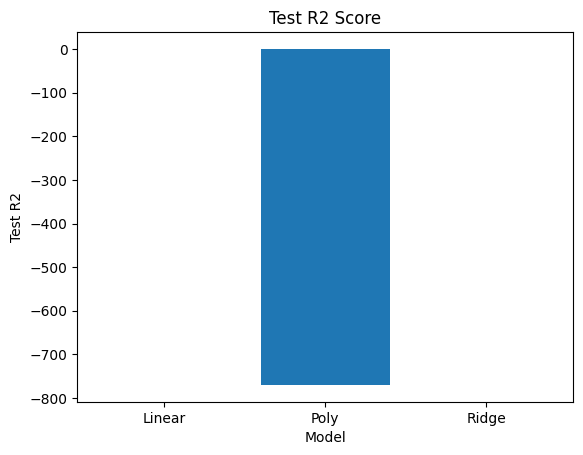

In [2]:
import numpy as np  # 수치 연산 및 배열 처리를 위한 라이브러리
import pandas as pd  # 데이터프레임 처리를 위한 라이브러리
import matplotlib.pyplot as plt  # 그래프 출력을 위한 라이브러리
import joblib  # 학습된 모델 및 데이터를 파일로 저장/로드

from sklearn.model_selection import train_test_split  # 훈련/테스트 데이터 분할
from sklearn.pipeline import Pipeline  # 전처리와 모델 학습 과정을 하나로 연결
from sklearn.preprocessing import StandardScaler, PolynomialFeatures  # 표준화와 다항 특성 변환
from sklearn.linear_model import LinearRegression, Ridge  # 선형 회귀와 릿지 회귀 모델
from sklearn.metrics import mean_squared_error  # MSE 평가 지표

# [조건 1] WHO 기대수명 데이터셋 로드 및 결측치 제거
url = 'https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv'
df = pd.read_csv(url)
df = df.dropna()

# [조건 1] 기존 실습 특성인 Schooling은 사용하지 않는다.
# 선택 특성: 과제 예시 변수 중 5개 선택
features = ['Adult mortality', 'BMI', 'GDP', 'Alcohol', 'Polio']
target = 'Life expectancy'

X = df[features]
y = df[target]

print('선택한 독립변수:', features)
print('사용하지 않은 특성: Schooling')
print('전체 데이터 크기:', X.shape)

# [조건 1] 전체 데이터를 80% 훈련, 20% 테스트로 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# [조건 1] 과대적합 관찰을 위해 훈련 데이터에서 무작위 50개 샘플만 추출
random_state = np.random.RandomState(42)
sample_index = random_state.choice(X_train.index, size=50, replace=False)
X_train_small = X_train.loc[sample_index]
y_train_small = y_train.loc[sample_index]

print('전체 훈련 데이터 크기:', X_train.shape)
print('테스트 데이터 크기:', X_test.shape)
print('실제 학습에 사용한 훈련 샘플 크기:', X_train_small.shape)

# [조건 2] Model 1: 1차 항 기본 선형 회귀 파이프라인
linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=1, include_bias=False)),
    ('model', LinearRegression())
])

# [조건 2] Model 2: 3차 다항 회귀 파이프라인, 규제 없음
poly_model = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('model', LinearRegression())
])

# [조건 2] Model 3: 3차 다항 회귀 + 릿지 규제 파이프라인
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('model', Ridge(alpha=1.0))
])

models = {
    'Linear': linear_model,
    'Poly': poly_model,
    'Ridge': ridge_model
}

# 3가지 모델 학습
for name, model in models.items():
    model.fit(X_train_small, y_train_small)
    print(name, '모델 학습 완료')

# [조건 2] 학습된 모델 객체를 .pkl 파일로 저장
joblib.dump(linear_model, 'linear_model.pkl')
joblib.dump(poly_model, 'poly_model.pkl')
joblib.dump(ridge_model, 'ridge_model.pkl')

# Streamlit 슬라이더 범위와 성능표를 app.py에서 사용하기 위한 메타데이터 저장
summary = []

for name, model in models.items():
    y_train_pred = model.predict(X_train_small)
    y_test_pred = model.predict(X_test)
    complexity = model.named_steps['poly'].get_feature_names_out(features).shape[0]

    summary.append({
        'Model': name,
        'Train R2': round(model.score(X_train_small, y_train_small), 4),
        'Test R2': round(model.score(X_test, y_test), 4),
        'Train MSE': round(mean_squared_error(y_train_small, y_train_pred), 4),
        'Test MSE': round(mean_squared_error(y_test, y_test_pred), 4),
        'Complexity': int(complexity)
    })

summary_df = pd.DataFrame(summary)
print('[조건 3] 모델 성능 비교표')
display(summary_df)

metadata = {
    'features': features,
    'summary': summary,
    'slider_info': {}
}

for feature in features:
    metadata['slider_info'][feature] = {
        'min': float(X[feature].min()),
        'max': float(X[feature].max()),
        'mean': float(X[feature].mean())
    }

joblib.dump(metadata, 'metadata.pkl')
summary_df.to_csv('model_performance.csv', index=False)

print('저장 완료: linear_model.pkl, poly_model.pkl, ridge_model.pkl, metadata.pkl, model_performance.csv')

# [조건 3] 3가지 모델의 Test R2 점수를 막대그래프로 비교
fig, ax = plt.subplots()
ax.bar(summary_df['Model'], summary_df['Test R2'])
ax.set_xlabel('Model')
ax.set_ylabel('Test R2')
ax.set_title('Test R2 Score')
plt.show()

### 3 단계: Streamlit 앱 파일 생성 (%%writefile app.py)
- 저장된 .pkl 파일을 불러와 웹 화면에서 모델 성능과 예측 결과를 출력한다.
- 과제 조건에 따라 st.dataframe, st.pyplot, st.sidebar.slider, st.selectbox를 사용한다.

In [3]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# [조건 2] joblib으로 저장한 3개 모델과 메타데이터 불러오기
linear_model = joblib.load('linear_model.pkl')
poly_model = joblib.load('poly_model.pkl')
ridge_model = joblib.load('ridge_model.pkl')
metadata = joblib.load('metadata.pkl')

models = {
    'Linear': linear_model,
    'Poly': poly_model,
    'Ridge': ridge_model
}

features = metadata['features']
slider_info = metadata['slider_info']
summary_df = pd.DataFrame(metadata['summary'])

# Streamlit 기본 화면 구성
st.title('WHO 기대수명 예측 웹 서비스')
st.write('Schooling 특성을 제외한 여러 특성으로 기대수명을 예측합니다.')

# [조건 3] 성능 평가지표 테이블 출력
st.subheader('각 모델의 성능 비교')
st.dataframe(summary_df)

# [조건 3] Test R2 점수 막대그래프 출력
fig, ax = plt.subplots()
ax.bar(summary_df['Model'], summary_df['Test R2'])
ax.set_xlabel('Model')
ax.set_ylabel('Test R2')
ax.set_title('Test R2 Score')
st.pyplot(fig)

# [조건 4] 사이드바 슬라이더 입력
st.sidebar.header('입력값 조절')
user_inputs = []

for feature in features:
    min_value = float(slider_info[feature]['min'])
    max_value = float(slider_info[feature]['max'])
    mean_value = float(slider_info[feature]['mean'])

    value = st.sidebar.slider(
        feature,
        min_value=min_value,
        max_value=max_value,
        value=mean_value
    )
    user_inputs.append(value)

# [조건 4] 모델 선택 인터페이스
# 과제 조건에서 st.selectbox를 이용해 Linear, Poly, Ridge 중 하나를 선택하도록 요구한다.
selected_model_name = st.selectbox(
    '사용할 모델 선택',
    ['Linear', 'Poly', 'Ridge']
)

selected_model = models[selected_model_name]

# [조건 4] 선택 모델로 실시간 기대수명 예측
input_data = np.array([user_inputs])
prediction = selected_model.predict(input_data)

st.subheader('실시간 기대수명 예측 결과')
st.write('선택 모델:', selected_model_name)
st.write('예측 기대수명:', round(prediction[0], 2), '세')

# 입력값 확인용 테이블
input_df = pd.DataFrame([user_inputs], columns=features)
st.table(input_df)


Writing app.py


### 4 단계: ngrok을 이용한 실시간 웹 배포 및 구동 코드

In [6]:
# 3. Streamlit 실행 및 ngrok 터널 연결
# 아래 코드는 9, 10, 11장 실습 파일의 실행 형식에 맞춘다.

!pip install streamlit pyngrok -q

import os
import time
from pyngrok import ngrok

# ngrok Authtoken 입력
# 아래 문자열 부분에 본인의 ngrok Authtoken을 붙여 넣고 실행한다.
ngrok.set_auth_token("본인_ngrok_토큰_붙여넣기")

# 3. Streamlit 실행 (서버 주소를 명시적으로 127.0.0.1로 고정하여 백그라운드 구동)
os.system("nohup streamlit run app.py --server.address 127.0.0.1 --server.port 8501 > /dev/null 2>&1 &")

# Streamlit 서버가 완전히 부팅될 때까지 3초간 대기
time.sleep(3)

# 4. ngrok 터널 연결 (8501 포트 열기)
public_url = ngrok.connect(8501, bind_tls=True)

print("=" * 60)
print(f"성공적으로 배포되었습니다! 아래 링크를 클릭하세요:\n{public_url}")
print("=" * 60)


성공적으로 배포되었습니다! 아래 링크를 클릭하세요:
NgrokTunnel: "https://knee-stained-dwarf.ngrok-free.dev" -> "http://localhost:8501"


### 5 단계: 실행 화면 캡처 첨부

아래 위치에 실제 모바일 또는 외부 PC로 접속한 Streamlit 화면 캡처본을 붙여 넣는다.

- 캡처 조건: URL 주소가 보이도록 캡처
- 확인 내용: 성능 비교표, Test R2 막대그래프, 슬라이더, 모델 선택, 예측 결과가 보이는 화면

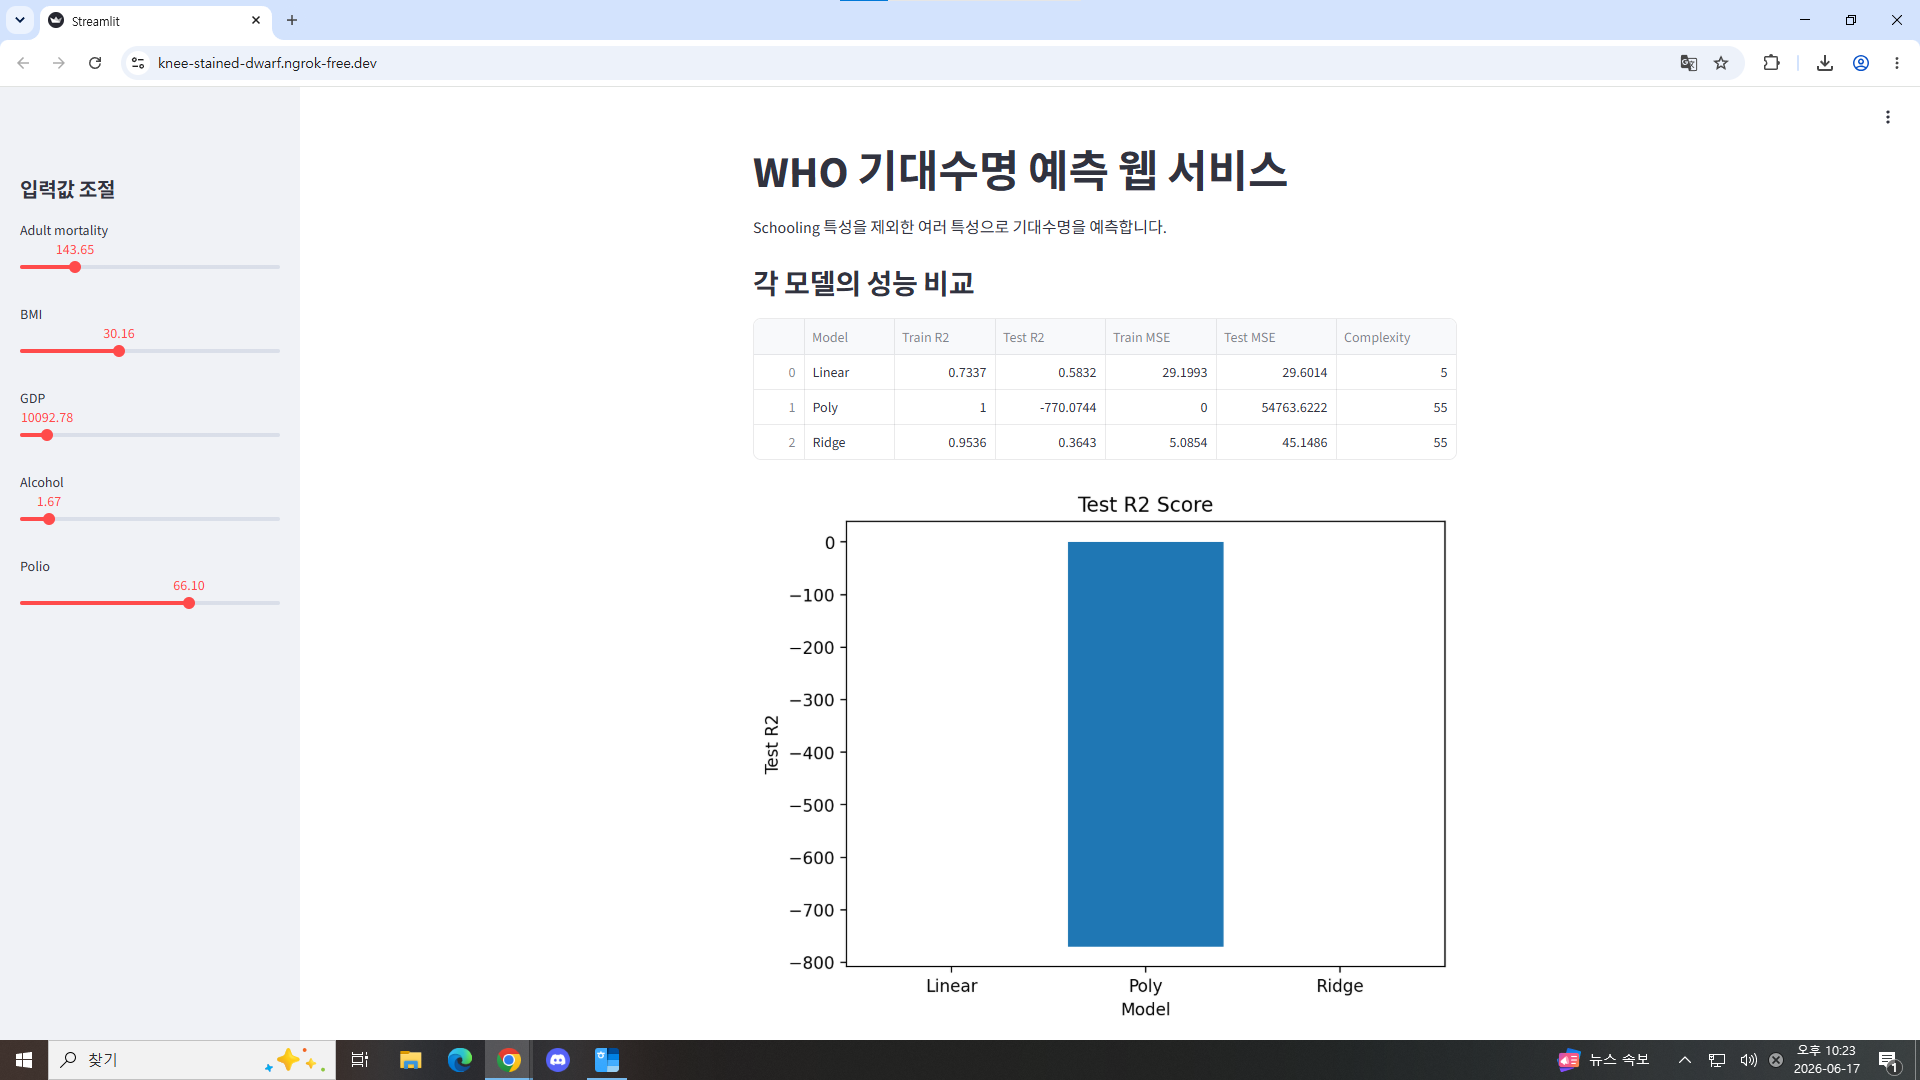

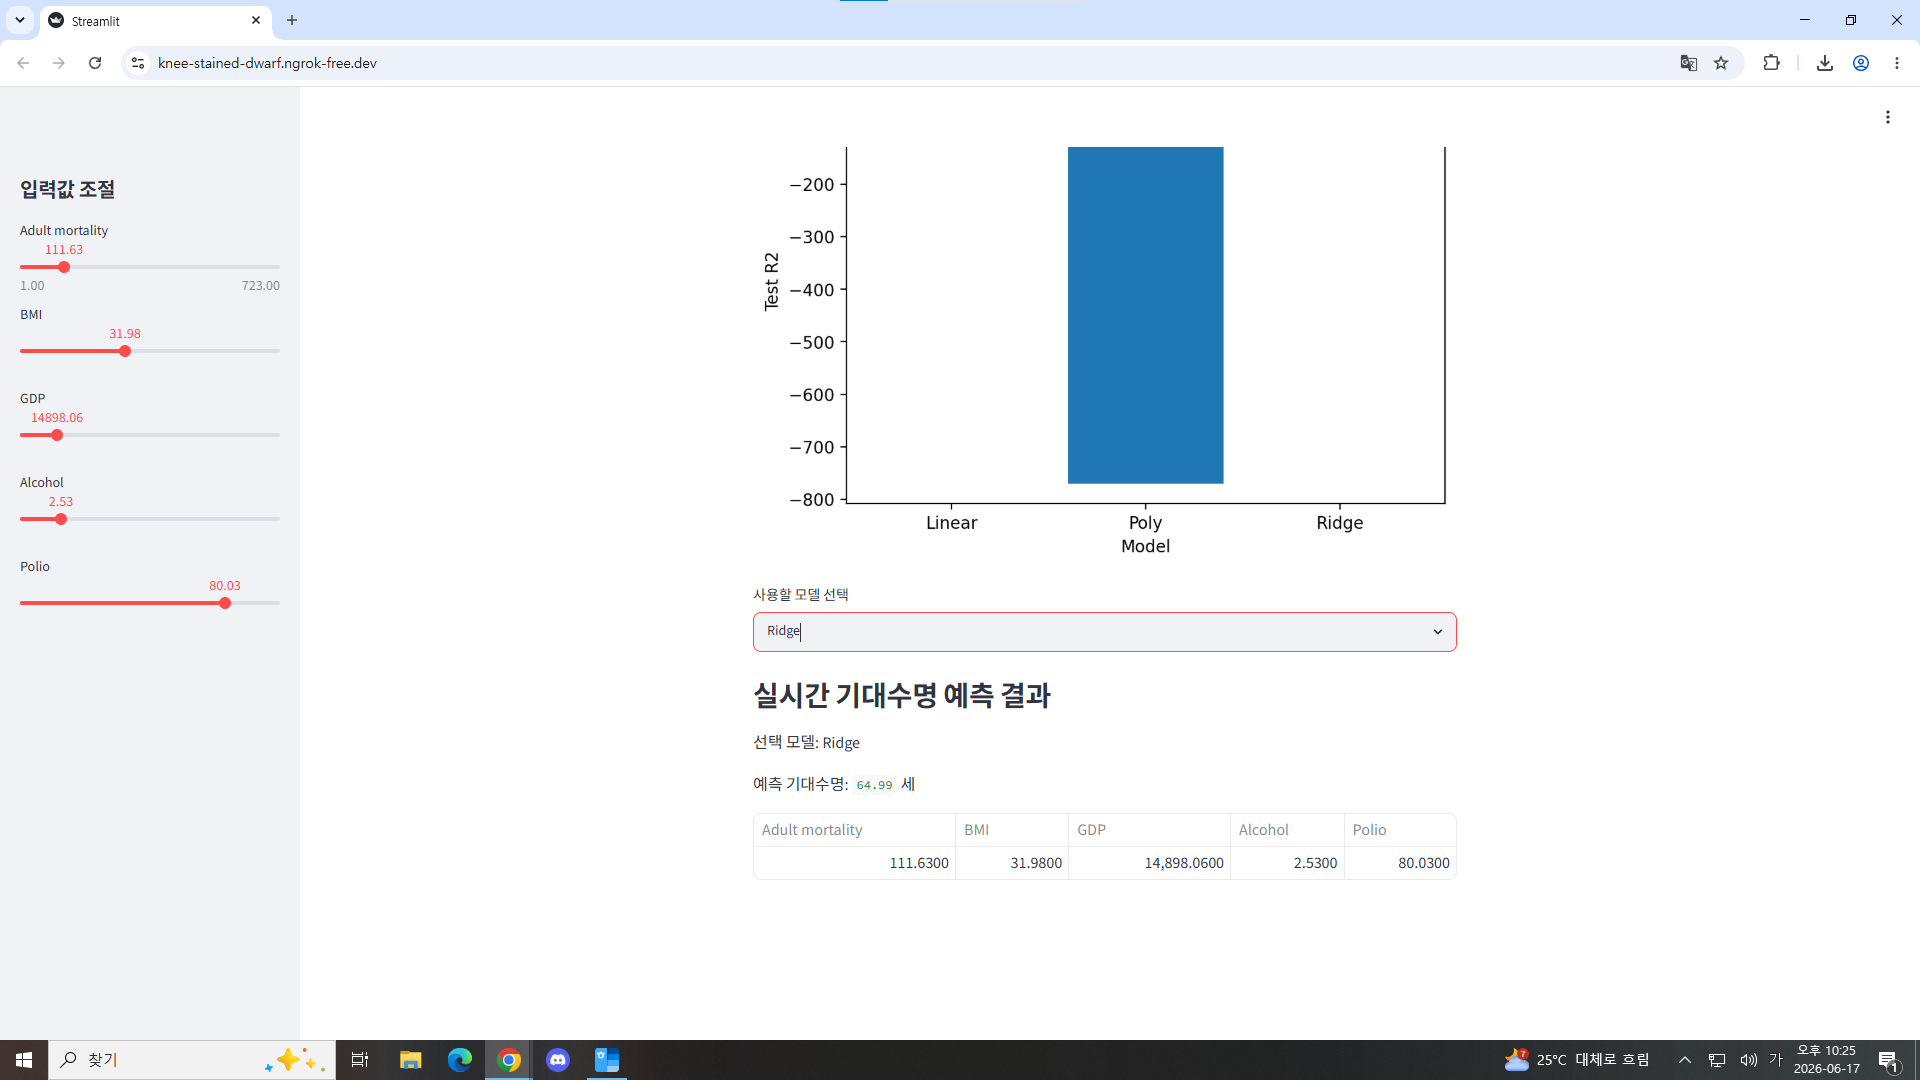

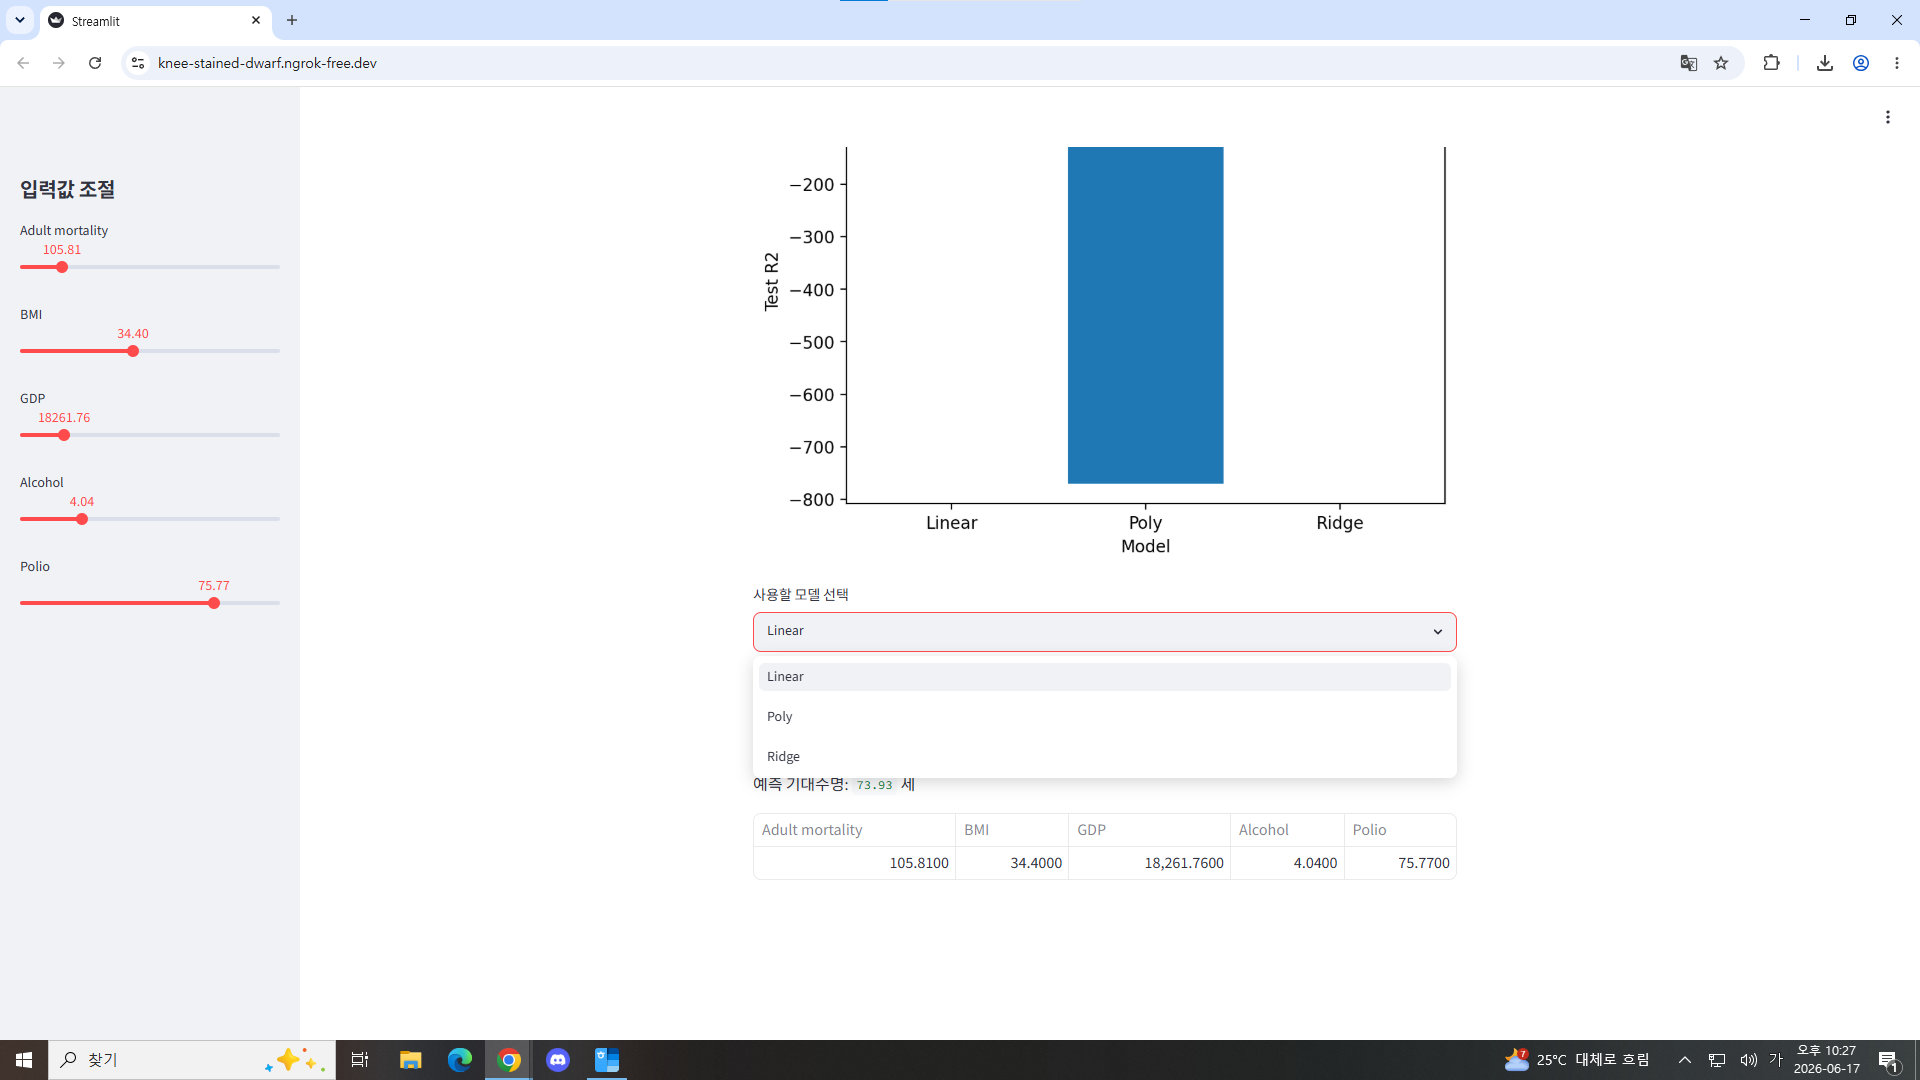